### 1. Basic Python API usage

Example: run a VCMA-assisted switching simulation.

In [4]:
from vgsot_sim import (
    vcma_assisted_switching_isot_sweep,
    VcmaAssistedSwitchingIsotSweepConfig,
)

cfg = VcmaAssistedSwitchingIsotSweepConfig(
    v_mtj=1.1,
    i_sot_list=[-40e-6, -30e-6, -20e-6],
)

result = vcma_assisted_switching_isot_sweep(cfg)

print(result.time_s.shape)

print(result.mz_curves.keys())
print(result.r_mtj_curves.keys())
print(result.pulse_curves.keys())

direct_excitation: 100%|███████████████████| 25000/25000 [00:00<00:00, 32392.95it/s]

(25001,)
dict_keys(['I_SOT=-40.0uA', 'I_SOT=-30.0uA', 'I_SOT=-20.0uA'])
dict_keys(['I_SOT=-40.0uA', 'I_SOT=-30.0uA', 'I_SOT=-20.0uA'])
dict_keys(['I_SOT=-40.0uA', 'I_SOT=-30.0uA', 'I_SOT=-20.0uA'])


### 2. plotting results (optional)

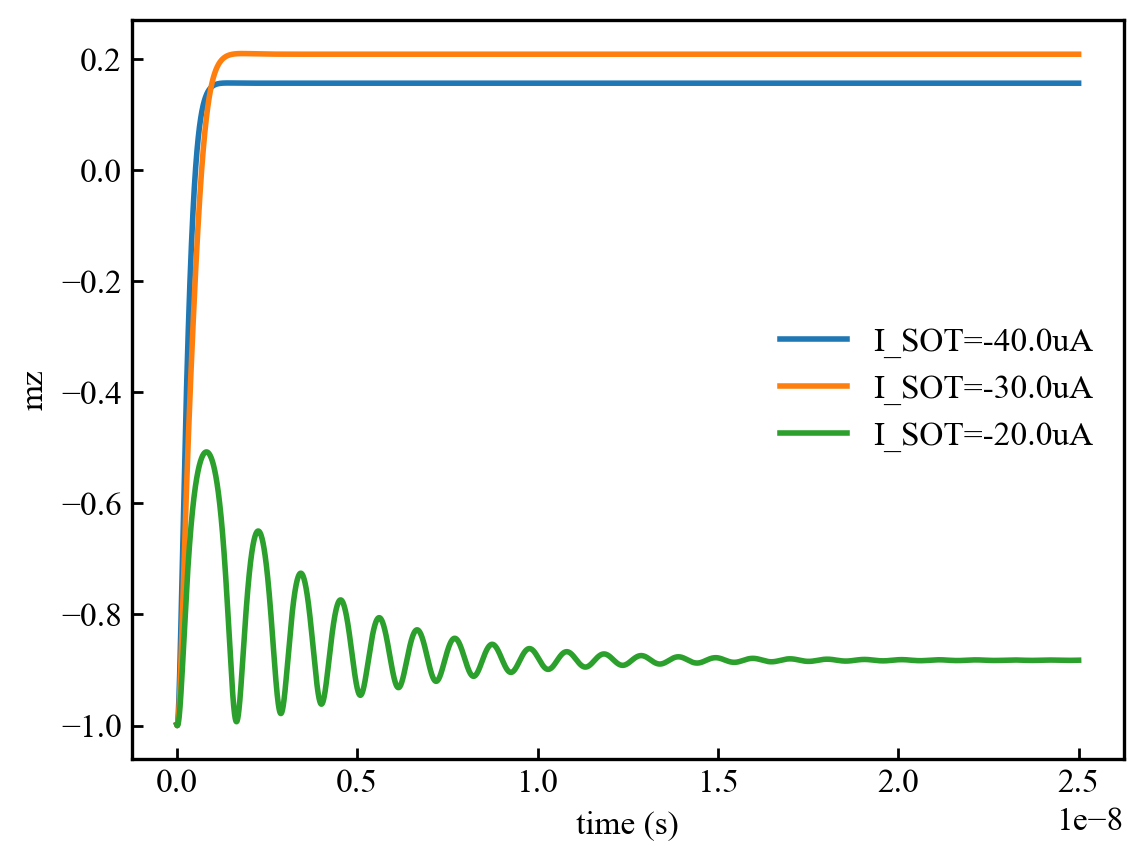

In [5]:
import matplotlib.pyplot as plt

for label, mz in result.mz_curves.items():
    plt.plot(result.time_s, mz, label=label)

plt.xlabel("time (s)")
plt.ylabel("mz")
plt.legend()
plt.show()

### 3. Running Monte-Carlo SER simulations

Example:

In [6]:
from vgsot_sim import (
    ser_sot_no_vcma_thermal,
    SerSotNoVcmaThermalConfig,
)

cfg = SerSotNoVcmaThermalConfig(
    trials=500,
    i_sot_list=[-100e-6, -95e-6, -90e-6],
)

res = ser_sot_no_vcma_thermal(cfg)

print(res.x)      # I_SOT values
print(res.ser)    # switching error rate

MC isot=-9.000e-05A: 100%|████████████████████████| 500/500 [01:18<00:00,  6.39it/s]

[-1.0e-04 -9.5e-05 -9.0e-05]
[0.81  0.71  0.232]


### 4. Low-level simulation kernels (advanced users)

If you want full control over excitation waveforms, you can call the internal kernels directly:

In [9]:
from vgsot_sim import run_piecewise_direct_excitation

res = run_piecewise_direct_excitation(
    sim_start_step=1,
    sim_mid1_step=2000,
    sim_mid2_step=3500,   # ← 新增
    sim_end_step=5000,

    pap=1,

    v_mtj_stage1=0.0,
    v_mtj_stage2=0.0,
    v_mtj_stage3=0.0,

    i_sot_stage1=-90e-6,
    i_sot_stage2=0.0,
    i_sot_stage3=0.0,

    estt_stage1=0,
    esot_stage1=1,

    estt_stage2=0,
    esot_stage2=1,

    estt_stage3=0,
    esot_stage3=1,

    vnv=1,
    non=1,

    r_sot_fl_dl=0.83,
)

print(res.time_s)
print(res.mz)

direct_excitation: 100%|█████████████████████| 5000/5000 [00:00<00:00, 23358.01it/s]

[0.000e+00 1.000e-12 2.000e-12 ... 4.998e-09 4.999e-09 5.000e-09]
[-0.9983532  -0.9989629  -0.9994106  ...  0.99280575  0.99218138
  0.99252234]
